In [1]:
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import art3d
from stl import mesh
from matplotlib import pyplot
import numpy as np
from PIL import Image
import io
import trimesh
from skimage import measure

## VIsualization

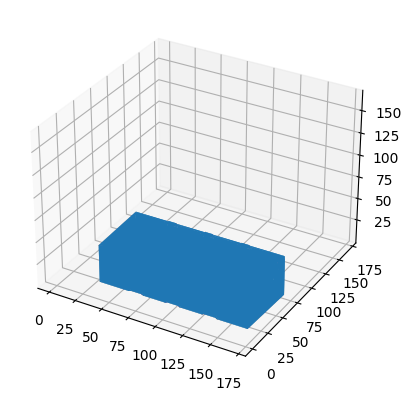

In [2]:
figure = pyplot.figure()
axes = figure.add_subplot(projection = '3d')
your_mesh = mesh.Mesh.from_file('test/test.STL')
axes.add_collection3d(mplot3d.art3d.Poly3DCollection(your_mesh.vectors))
scale = your_mesh.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)
pyplot.show()

## Preprocessing

In [4]:
def compute_shared_centroid_scale(stl_paths):
    centroids = []
    scales = []
    for path in stl_paths:
        mesh = trimesh.load_mesh(path)
        centroids.append(mesh.centroid)
        scales.append(mesh.bounding_box.extents.max())
    shared_centroid = np.mean(centroids, axis = 0)
    shared_scale = 1.0 / max(scales)
    return shared_centroid, shared_scale

In [5]:
def stl_to_voxel_grid(stl_path, centroid, scale, resolution = 128):
    mesh = trimesh.load_mesh(stl_path)
    mesh.apply_translation(-centroid)
    mesh.apply_scale(scale)
    voxels = mesh.voxelized(pitch = 1.0 / resolution).matrix.astype(np.uint8)
    if voxels.shape != (resolution, resolution, resolution):
        padded = np.zeros((resolution, resolution, resolution), dtype = np.uint8)
        min_shape = np.minimum(voxels.shape, padded.shape)
        padded[:min_shape[0], :min_shape[1], :min_shape[2]] = voxels[:min_shape[0], :min_shape[1], :min_shape[2]]
        voxels = padded
    return voxels

In [6]:
def voxel_grid_to_stl(voxels, output_path, centroid, scale):
    verts, faces, _, _ = measure.marching_cubes(voxels, level = 0.5)
    verts = verts / voxels.shape[0]
    verts = verts / scale
    verts = verts + centroid
    mesh = trimesh.Trimesh(vertices=verts, faces=faces)
    mesh.export(output_path)
    print(f"Exported to {output_path}")

In [12]:
def run_pipeline(input_stl, output_stl, centroid, scale, resolution = 128):
    print("[1] STL to Voxel...")
    voxels = stl_to_voxel_grid(input_stl, centroid, scale, resolution)
    print("The shape is", voxels.shape)
    print("[2] Voxel to STL...")
    voxel_grid_to_stl(voxels, output_stl, centroid, scale)

In [7]:
shared_centroid, shared_scale = compute_shared_centroid_scale(['test/test.STL'])
shared_centroid, shared_scale

(array([99.16119831, 48.49260374, 24.54928909]), 0.007172048918824383)

In [42]:
run_pipeline("test/test.STL", "output/out.STL", shared_centroid, shared_scale, resolution = 128)

[1] STL to Voxel...
The shape is (128, 128, 128)
[2] Voxel to STL...
Exported to output/out.STL


In [43]:
mesh = trimesh.load_mesh('test/test.STL')
mesh.show()

In [44]:
output_mesh = trimesh.load_mesh('output/out.STL')
output_mesh.show()

In [45]:
mesh.bounding_box.extents, output_mesh.bounding_box.extents

(array([139.43017 ,  58.70001 ,  45.780183]),
 array([138.34085846,  59.36675644,  46.29516983]))